# Comparing the quality of chromatin accessibility profiling generated by dATAC and s3-ATAC

# Import R libraries

In [22]:
suppressPackageStartupMessages({
    library("ArchR")
    library("dplyr")
    library("Matrix")
    library("msigdbr")
    library("GSVA")
    library("readr")
    library("stringr")
    library("BSgenome.Hsapiens.UCSC.hg38")
    library("reticulate")
    library("eulerr")
    library("ggplot2")
})

## Load ArchR project

In [23]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

# Set thread count
addArchRThreads(threads = 1)

# Load ArchR project

proj <- loadArchRProject(path = "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New",
                         force = FALSE)

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

## Dimensionality reduction and clustering

In [4]:
# LSI dimensionality reduction
proj <- addIterativeLSI(
  ArchRProj = proj,
  useMatrix = "TileMatrix", 
  name = "IterativeLSI", 
  iterations = 4, 
  clusterParams = list( #See Seurat::FindClusters
    resolution =c(0.1,0.5,1,2), 
    sampleCells = 10000, 
    n.start = 10
  ), 
  varFeatures = 25000, 
  dimsToUse = 1:30,
  force = TRUE
)

# Batch effect correction 
Mode <- c()
Mode[grep("_ATAC", proj$cellNames)] <- "ATAC"
Mode[grep("_DATAC", proj$cellNames)] <- "DATAC"
proj$Mode <- Mode

# batch effect correction
proj <- addHarmony(
  ArchRProj = proj,
  reducedDims = "IterativeLSI",
  name = "Harmony",
  groupBy = c("Mode"),
  force = TRUE,
  seed = 7
)

# Clustering using Seurat

proj <- addClusters(
    input = proj,
    reducedDims = "Harmony",
    method = "Seurat",
    name = "Clusters",
    resolution = 0.1,
    dimsToUse = c(1:30), 
    scaleDims=NULL,
    maxClusters = 50,
    force = TRUE
  )


proj <- addUMAP(
  ArchRProj = proj, 
  reducedDims = "Harmony", 
  name = "UMAP", 
  nNeighbors = 30, 
  minDist = 0.5, 
  metric = "cosine",
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-8bee3c1d877d-Date-2026-09-11_Time-10-16-18.155358.log
If there is an issue, please report to github with logFile!

2026-09-11 10:16:20.561687 : Computing Total Across All Features, 0.014 mins elapsed.

2026-09-11 10:16:24.057448 : Computing Top Features, 0.072 mins elapsed.

###########
2026-09-11 10:16:24.722832 : Running LSI (1 of 4) on Top Features, 0.083 mins elapsed.
###########

2026-09-11 10:16:24.733128 : Creating Partial Matrix, 0.083 mins elapsed.

2026-09-11 10:17:38.743478 : Computing LSI, 1.317 mins elapsed.

2026-09-11 10:18:02.201372 : Identifying Clusters, 1.708 mins elapsed.

Warning message:
“package ‘sp’ was built under R version 4.3.3”
2026-09-11 10:18:15.036496 : Identified 8 Clusters, 1.922 mins elapsed.

2026-09-11 10:18:15.075182 : Saving LSI Iteration, 1.922 mins elapsed.

Warning message:
“package ‘uwot’ was built under R version 4.3.3”
Warning message:
“The `size` argument of `element_line

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7824
Number of edges: 323073

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9585
Number of communities: 5
Elapsed time: 0 seconds


2026-09-11 10:29:42.413275 : Testing Biased Clusters, 0.124 mins elapsed.

2026-09-11 10:29:42.436377 : Testing Outlier Clusters, 0.124 mins elapsed.

2026-09-11 10:29:42.452381 : Assigning Cluster Names to 5 Clusters, 0.124 mins elapsed.

2026-09-11 10:29:42.503334 : Finished addClusters, 0.125 mins elapsed.

10:29:42 UMAP embedding parameters a = 0.583 b = 1.334

10:29:42 Read 7824 rows and found 29 numeric columns

10:29:42 Using Annoy for neighbor search, n_neighbors = 30

10:29:42 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:29:43 Writing NN index file to temp file /var/folders/f3/1rtmfwtj5bg3c32s2xf8fpdn1m18m5/T//Rtmp5uYkII/file8bee8b03b94

10:29:43 Searching Annoy index using 4 threads, search_k = 3000

10:29:43 Annoy recall = 100%

10:29:44 Commencing smo

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8bee200a0cba-Date-2026-09-11_Time-10-34-05.753508.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8bee200a0cba-Date-2026-09-11_Time-10-34-05.753508.log



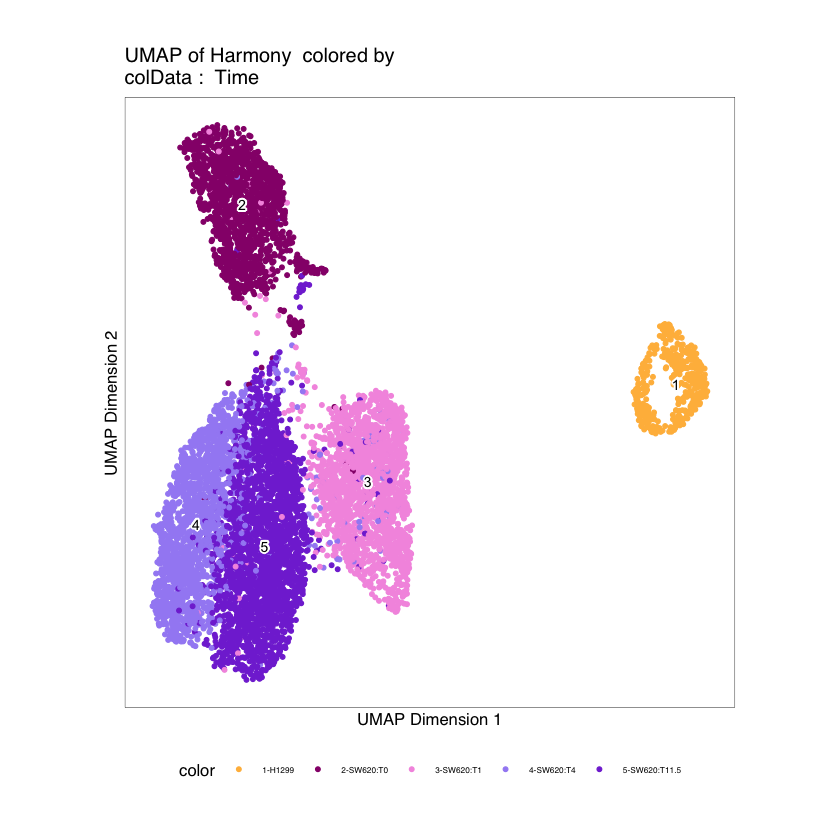

In [5]:
# Chromatin accessibility UMAP colored by cell line:timepoint

time <- c()
time[grep("POTa|POTb", proj$cellNames)] <- "SW620:T0"
time[grep("DSIa|DSIb", proj$cellNames)] <- "SW620:T1"
time[grep("DSIVa|DSIVb", proj$cellNames)] <- "SW620:T4"
time[grep("DT1_P1a|DT1_P1b", proj$cellNames)] <- "SW620:T11.5"
time[grep("H1299", proj$cellNames)] <- "H1299"

proj$Time <- time

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Time", embedding = "UMAP",
                    size = 1,
                    pal = c("SW620:T0" = "#961179",
                            "SW620:T1" =  "#F49AE1",
                            "SW620:T4" = "#A48EF4",
                            "SW620:T11.5"= "#8239D6",
                            "H1299" = "#ffba49"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 20, # Adjust this value
                      baseSize = 24 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)
p1

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8bee6c72ad89-Date-2026-09-11_Time-10-34-55.573609.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8bee6c72ad89-Date-2026-09-11_Time-10-34-55.573609.log



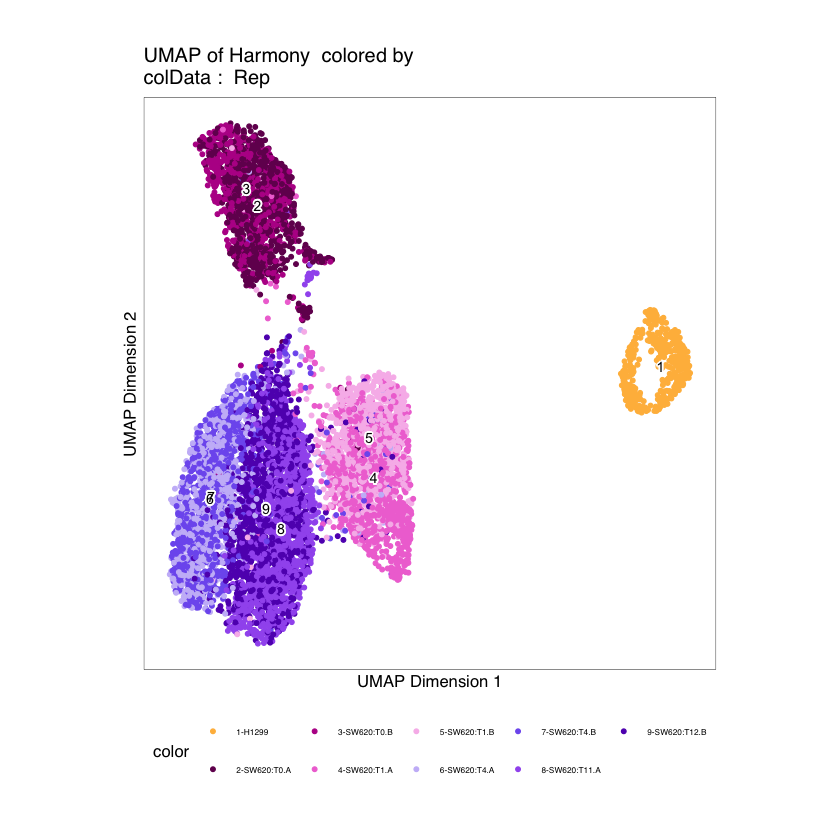

In [6]:
# Chromatin accessibility UMAP colored by cell line:replicate

rep <- c()
rep[grep("POTa", proj$cellNames)] <- "SW620:T0.A"
rep[grep("POTb", proj$cellNames)] <- "SW620:T0.B"
rep[grep("DSIa", proj$cellNames)] <- "SW620:T1.A"
rep[grep("DSIb", proj$cellNames)] <- "SW620:T1.B"
rep[grep("DSIVa", proj$cellNames)] <- "SW620:T4.A"
rep[grep("DSIVb", proj$cellNames)] <- "SW620:T4.B"
rep[grep("DT1_P1a", proj$cellNames)] <- "SW620:T11.A"
rep[grep("DT1_P1b", proj$cellNames)] <- "SW620:T12.B"
rep[grep("H1299", proj$cellNames)] <- "H1299"

proj$Rep <- rep

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Rep", embedding = "UMAP",
                    size = 1,
                    pal = c("SW620:T0.A" = "#730d5d",
                            "SW620:T0.B" = "#b81595",
                            "SW620:T1.A" =  "#f077d6",
                            "SW620:T1.B" =  "#f8bceb",
                            "SW620:T4.A" = "#c9bcf8",
                            "SW620:T4.B" = "#7e60ef",
                            "SW620:T11.A"= "#a25fef",
                            "SW620:T12.B"= "#6113bc",
                            "H1299" = "#ffba49"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 20, # Adjust this value
                      baseSize = 24 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)
p1

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-8bee188d3f94-Date-2026-09-11_Time-10-35-05.868247.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-8bee188d3f94-Date-2026-09-11_Time-10-35-05.868247.log



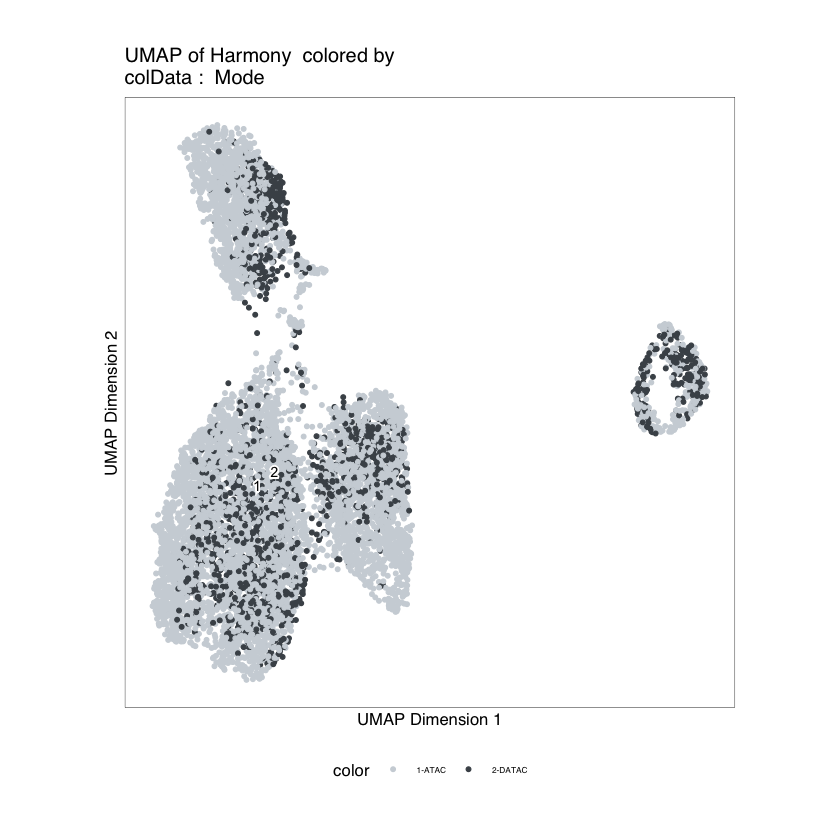

In [7]:
# Chromatin accessibility UMAP colored by assay (dATAC vs s3-ATAC)

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Mode", embedding = "UMAP",
                    size = 1,
                    pal = c("ATAC" = "#ced4da",
                            "DATAC" =  "#495057"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 24, # Adjust this value
                      baseSize = 30 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)

p1

## Call peaks to compare FRIP and correlations between dATAC and s3-ATAC

In [8]:
# Add group coverages for peak calling
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "Clusters")

# Set the path to Macs2
pathToMacs2 <- findMacs2()

# Call peaks using Macs2
proj <- addReproduciblePeakSet(
  ArchRProj = proj, 
  groupBy = "Clusters", 
  pathToMacs2 = pathToMacs2
)

# Retrieve a GRanges object containing the peak information (position, signal, etc.)
peaks <- getPeakSet(proj)

# Add peak matrix to the project
proj <- addPeakMatrix(proj)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-8bee2d0e1928-Date-2026-09-11_Time-10-35-18.350494.log
If there is an issue, please report to github with logFile!

C1 (1 of 5) : CellGroups N = 2

C2 (2 of 5) : CellGroups N = 2

C3 (3 of 5) : CellGroups N = 4

C4 (4 of 5) : CellGroups N = 5

C5 (5 of 5) : CellGroups N = 5

2026-09-11 10:35:20.321395 : Further Sampled 6 Groups above the Max Fragments!, 0.033 mins elapsed.

2026-09-11 10:35:20.608947 : Creating Coverage Files!, 0.038 mins elapsed.

2026-09-11 10:35:20.610945 : Batch Execution w/ safelapply!, 0.038 mins elapsed.

2026-09-11 10:35:20.668514 : Group C1._.H1299_ATAC (1 of 18) : Creating Group Coverage File : C1._.H1299_ATAC.insertions.coverage.h5, 0.039 mins elapsed.

Number of Cells = 215

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2026-09-11 10:35:50.936092 : Group C1._.H1299_DATAC (2 of 18) : Creating Group Coverage F

   Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
C1    C1    396        396           2  181  215   150000
C2    C2     66         61           2   40   40    30500
C3    C3   1524       1289           4  125  500   150000
C4    C4   1790       1414           5   74  500   150000
C5    C5   4048       2316           5  316  500   150000


2026-09-11 10:50:36.09859 : Batching Peak Calls!, 0.012 mins elapsed.

2026-09-11 10:50:36.293747 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-09-11 10:50:36.307494 : Group 1 of 18, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 2.7e+09 --name C1._.H1299_ATAC-1 --treatment /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/PeakCalls/Clusters/InsertionBeds/C1._.H1299_ATAC-1.insertions.bed --outdir /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/PeakCalls/Clusters/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.1

2026-09-11 10:52:10.92906 : Group 2 of 18, Calling Peaks with MACS2!, 1.577 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 2.7e+09 -

[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/PeakCalls/Clusters/C1-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



...

Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/PeakCalls/Clusters/C4-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/PeakCalls/Clusters/C5-reproduciblePeaks.gr.rds"


2026-09-11 11:12:21.192041 : Creating Union Peak Set!, 21.764 mins elapsed.

Converged after 8 iterations!

Plotting Ggplot!

2026-09-11 11:12:25.695376 : Finished Creating Union Peak Set (236207)!, 21.839 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-8bee477d6cc5-Date-2026-09-11_Time-11-12-25.713649.log
If there is an issue, please report to github with logFile!

2026-09-11 11:12:26.085391 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-09-11 11:12:26.708114 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (1 of 23)!, 0.009 mins elapsed.

2026-09-11 11:12:36.479862 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (2 of 23)!, 0.172 mins elapsed.

2026-09-11 11:12:42.905253 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (3 of 23)!, 0.279 mins elapsed.

2026-09-11 11:12:48.267701 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (4 of 23)!, 0.368 mins elapsed.

2026-09-11 11:12:52.197307 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (5 of 23)!, 0.434 mins el

In [21]:
saveArchRProject(proj, "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New")

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New 
samples(18): SW620bc_DSIa_ATAC SW620bc_DT1_P1a_ATAC ...
  SW620bc_DSIVb_DATAC SW620bc_DSIVa_DATAC
sampleColData names(1): ArrowFiles
cellColData names(22): Sample TSSEnrichment ... FRIP RepMode
numberOfCells(1): 7824
medianTSS(1): 8.6325
medianFrags(1): 72555

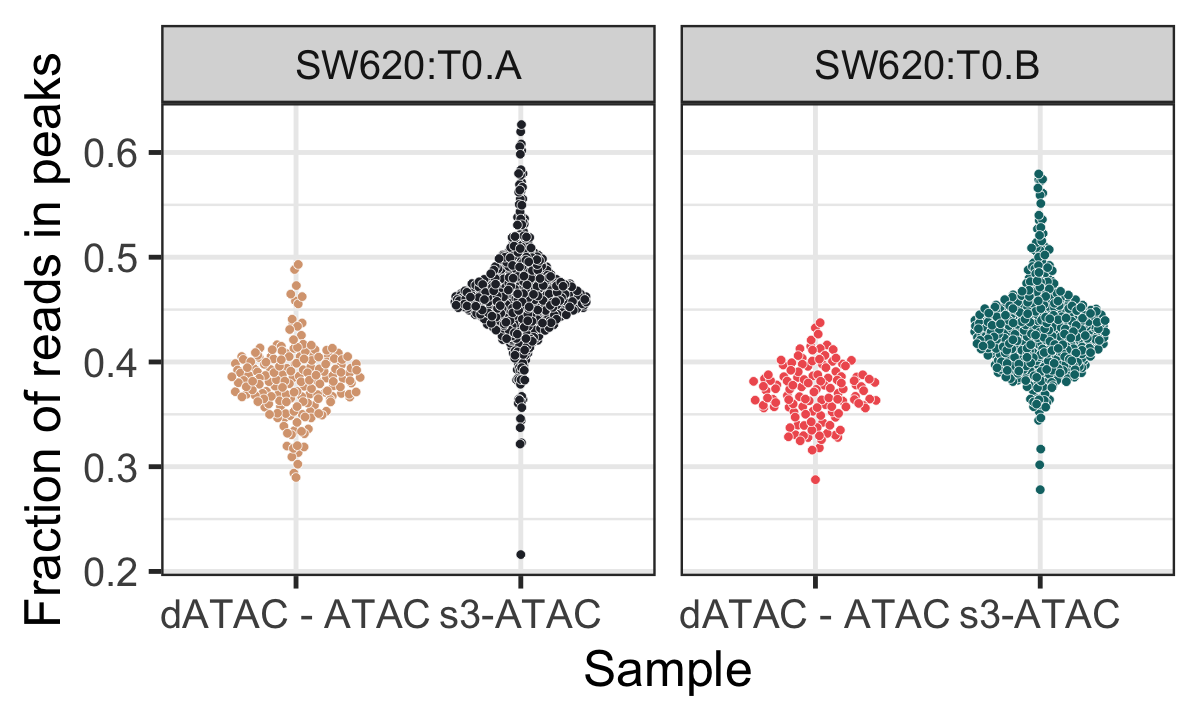

In [10]:
library(ggbeeswarm)

df <- data.frame(proj@cellColData[proj@cellColData$Time %in% c("SW620:T0"),]) %>% mutate(Mode = case_when(Mode == "ATAC"~ "s3-ATAC",
                                                                                                  Mode == "DATAC" ~ "dATAC - ATAC"))
p <- ggplot(data = df, aes(x = Mode, y =FRIP,  fill = Sample))+
  geom_quasirandom(
    dodge.width = 0.75,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 2.5,
    stroke = 0.3,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  scale_color_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                                "SW620bc_POTb_DATAC" ="#f05d5e",
                                "SW620bc_POTb_ATAC" ="#0f7173",
                                "SW620bc_POTa_ATAC" ="#272932"))+
  scale_fill_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                               "SW620bc_POTb_DATAC" ="#f05d5e",
                               "SW620bc_POTb_ATAC" ="#0f7173",
                               "SW620bc_POTa_ATAC" ="#272932"))+
  facet_wrap(vars(Rep), scales = "free_x", nrow = 1)+
  xlab("Sample")+
  ylab("Fraction of reads in peaks")+
  guides(color = "none", fill = "none")+
  theme_bw(base_size = 30)
options(repr.plot.width=10, repr.plot.height=6)

p

In [11]:
rep <- c()
rep[grep("POTa_ATAC", proj$cellNames)] <- "s3-ATAC: T0.A"
rep[grep("POTa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T0.A"

rep[grep("POTb_ATAC", proj$cellNames)] <- "s3-ATAC: T0.B"
rep[grep("POTb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T0.B"

rep[grep("DSIa_ATAC", proj$cellNames)] <- "s3-ATAC: T1.A"
rep[grep("DSIa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T1.A"

rep[grep("DSIb_ATAC", proj$cellNames)] <- "s3-ATAC: T1.B"
rep[grep("DSIb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T1.B"

rep[grep("DSIVa_ATAC", proj$cellNames)] <- "s3-ATAC: T4.A"
rep[grep("DSIVa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T4.A"

rep[grep("DSIVb_ATAC", proj$cellNames)] <- "s3-ATAC: T4.B"
rep[grep("DSIVb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T4.B"

rep[grep("DT1_P1a_ATAC", proj$cellNames)] <- "s3-ATAC: T11.A"
rep[grep("DT1_P1a_DATAC", proj$cellNames)] <- "dATAC - ATAC: T11.A"

rep[grep("DT1_P1b_ATAC", proj$cellNames)] <- "s3-ATAC: T12.B"
rep[grep("DT1_P1b_DATAC", proj$cellNames)] <- "dATAC - ATAC: T12.B"

rep[grep("H1299_ATAC", proj$cellNames)] <- "s3-ATAC: H1299"
rep[grep("H1299_DATAC", proj$cellNames)] <- "dATAC - ATAC: H1299"

proj$RepMode <- rep

proj$RepMode <- factor(
  proj$RepMode,
  levels = c("s3-ATAC: T0.A", "dATAC - ATAC: T0.A",
             "s3-ATAC: T0.B", "dATAC - ATAC: T0.B",
            "s3-ATAC: T1.A", "dATAC - ATAC: T1.A",
              "s3-ATAC: T1.B", "dATAC - ATAC: T1.B",
            "s3-ATAC: T4.A", "dATAC - ATAC: T4.A",
             "s3-ATAC: T4.B", "dATAC - ATAC: T4.B",
            "s3-ATAC: T11.A", "dATAC - ATAC: T11.A",
              "s3-ATAC: T12.B", "dATAC - ATAC: T12.B",
            "s3-ATAC: H1299", "dATAC - ATAC: H1299")  # your desired order
)

In [12]:
# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj,
  groupBy = "RepMode",
  normMethod = "ReadsInTSS",
  tileSize = 1000,
)

ArchR logging to : ArchRLogs/ArchR-getGroupBW-8bee40b158b2-Date-2026-09-11_Time-12-19-49.395901.log
If there is an issue, please report to github with logFile!

2026-09-11 12:19:50.995279 : s3-ATAC: T0.A (1 of 18) : Creating BigWig for Group, 0.027 mins elapsed.

2026-09-11 12:20:11.6063 : dATAC - ATAC: T0.A (2 of 18) : Creating BigWig for Group, 0.37 mins elapsed.

2026-09-11 12:20:16.229885 : s3-ATAC: T0.B (3 of 18) : Creating BigWig for Group, 0.447 mins elapsed.

2026-09-11 12:20:34.475951 : dATAC - ATAC: T0.B (4 of 18) : Creating BigWig for Group, 0.751 mins elapsed.

2026-09-11 12:20:37.503135 : s3-ATAC: T1.A (5 of 18) : Creating BigWig for Group, 0.802 mins elapsed.

2026-09-11 12:21:20.654708 : dATAC - ATAC: T1.A (6 of 18) : Creating BigWig for Group, 1.521 mins elapsed.

2026-09-11 12:21:26.394757 : s3-ATAC: T1.B (7 of 18) : Creating BigWig for Group, 1.617 mins elapsed.

2026-09-11 12:21:45.84687 : dATAC - ATAC: T1.B (8 of 18) : Creating BigWig for Group, 1.941 mins elapsed.


[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T0.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
 [2] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T0.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
 [3] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T0.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
 [4] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T0.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
 [5] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T1.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
 [6] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T1.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
 [7] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T1.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
 [8] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T1.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
 [9] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T4.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
[10] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T4.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
[11] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T4.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"      
[12] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T4.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw" 
[13] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T11.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"     
[14] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T11.A-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"
[15] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/s3.ATAC..T12.B-TileSize-1000-normMethod-ReadsInTSS-ArchR.bw"     
[16] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode/dATAC...ATAC..T12.B

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


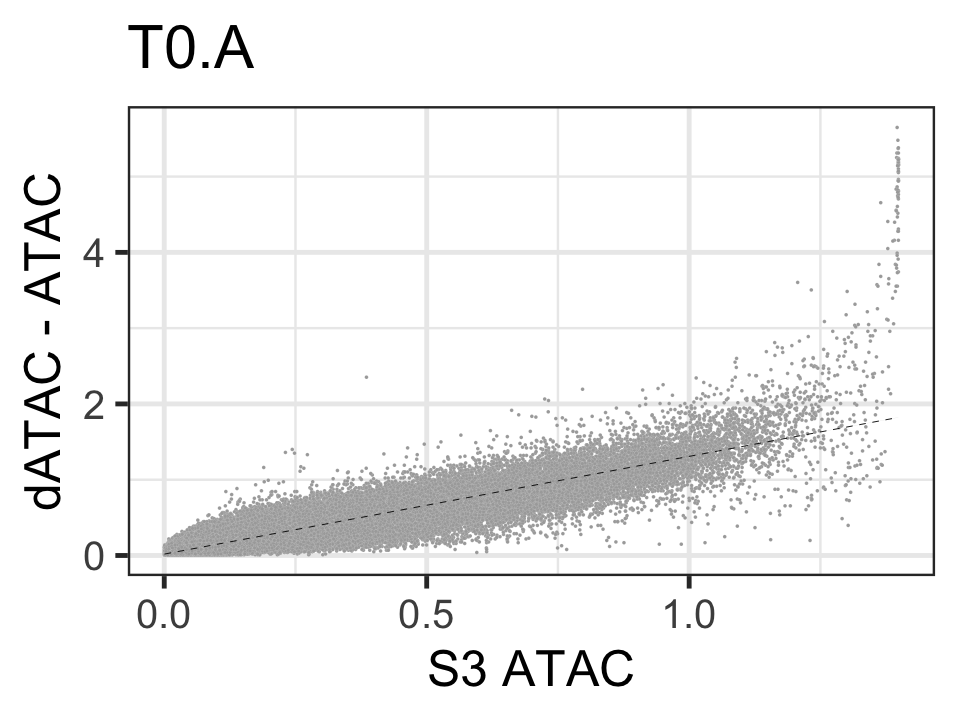

`geom_smooth()` using formula = 'y ~ x'


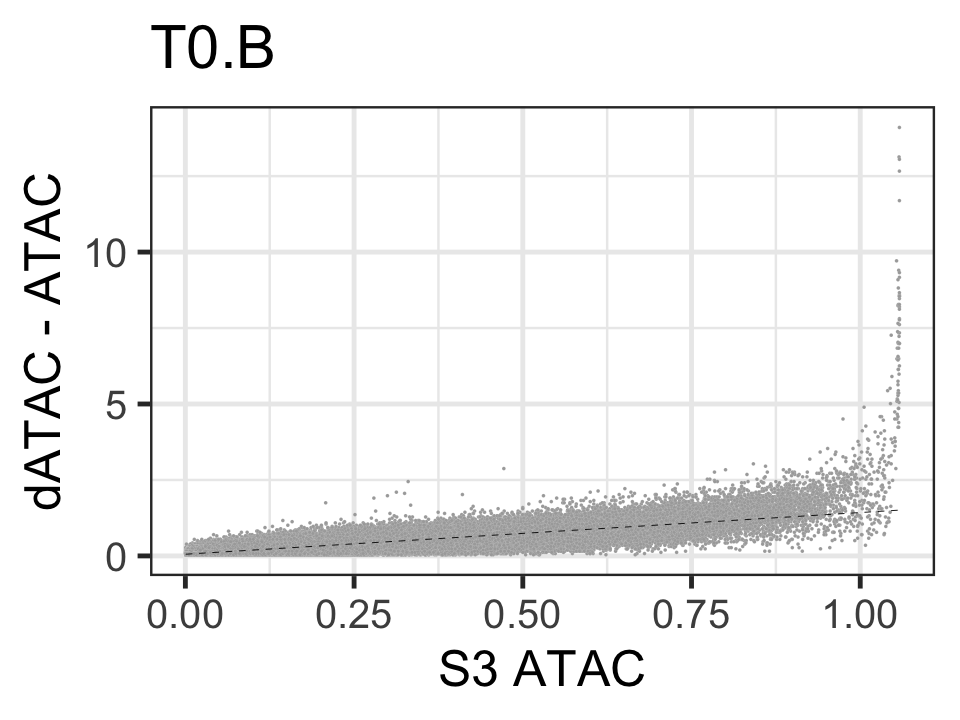

`geom_smooth()` using formula = 'y ~ x'


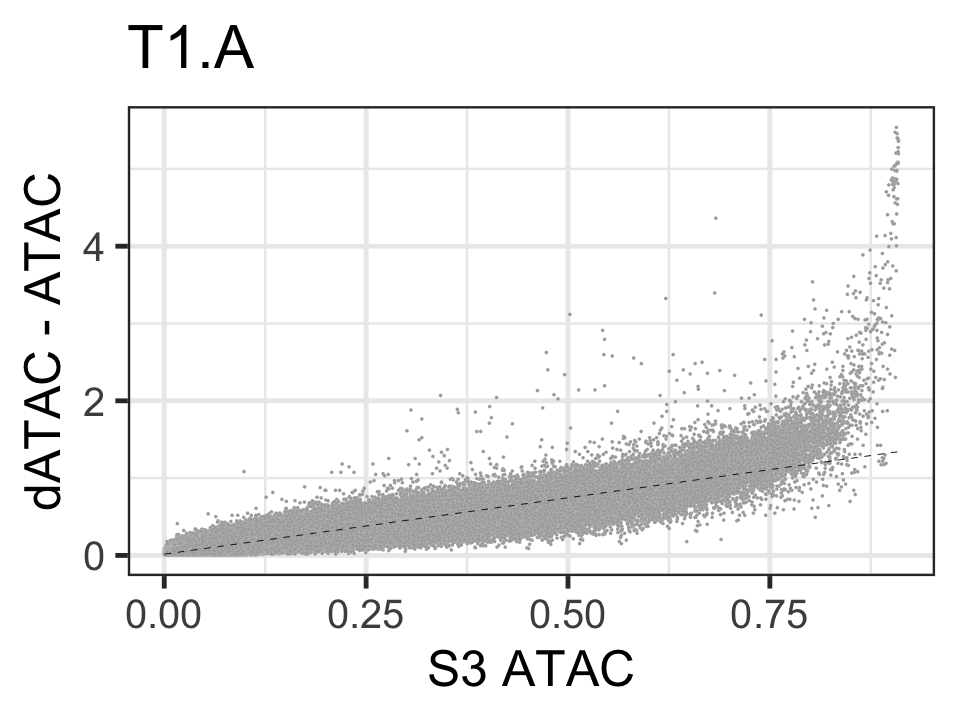

`geom_smooth()` using formula = 'y ~ x'


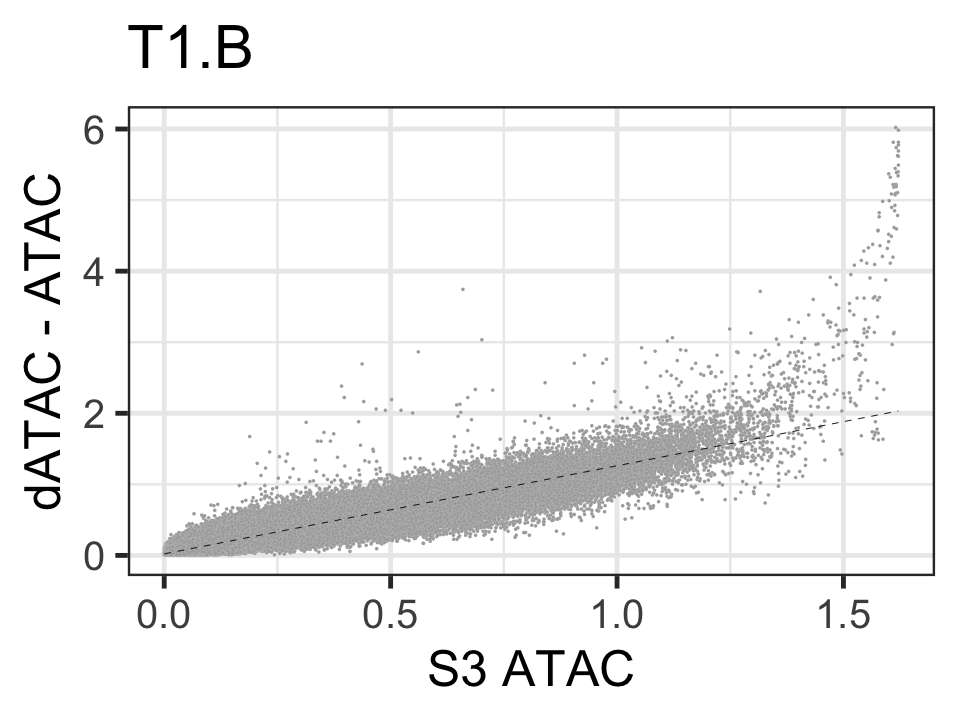

`geom_smooth()` using formula = 'y ~ x'


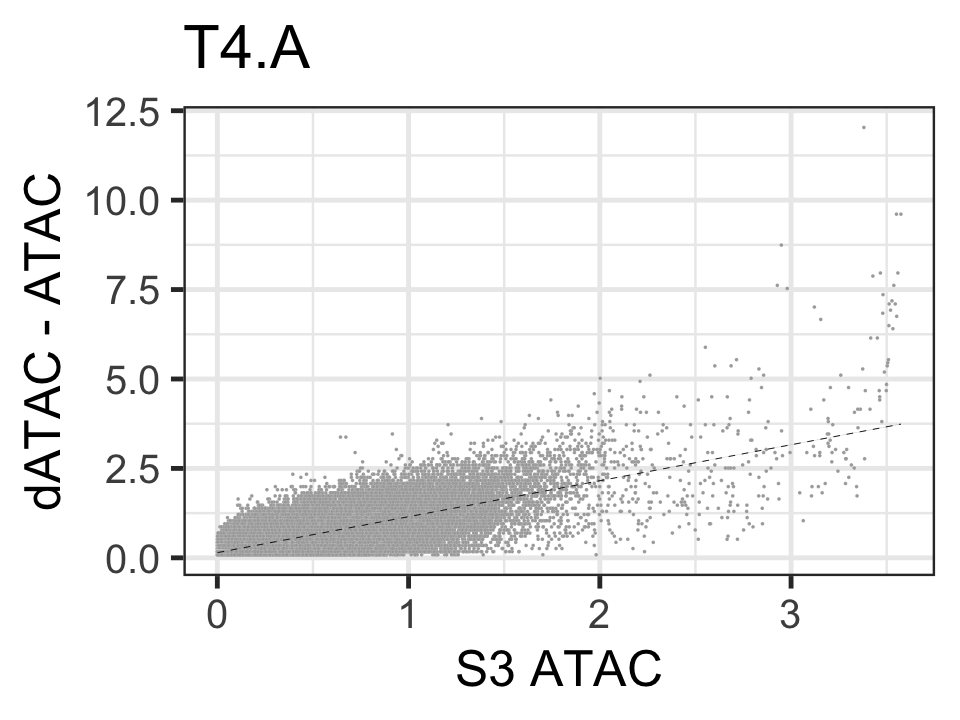

`geom_smooth()` using formula = 'y ~ x'


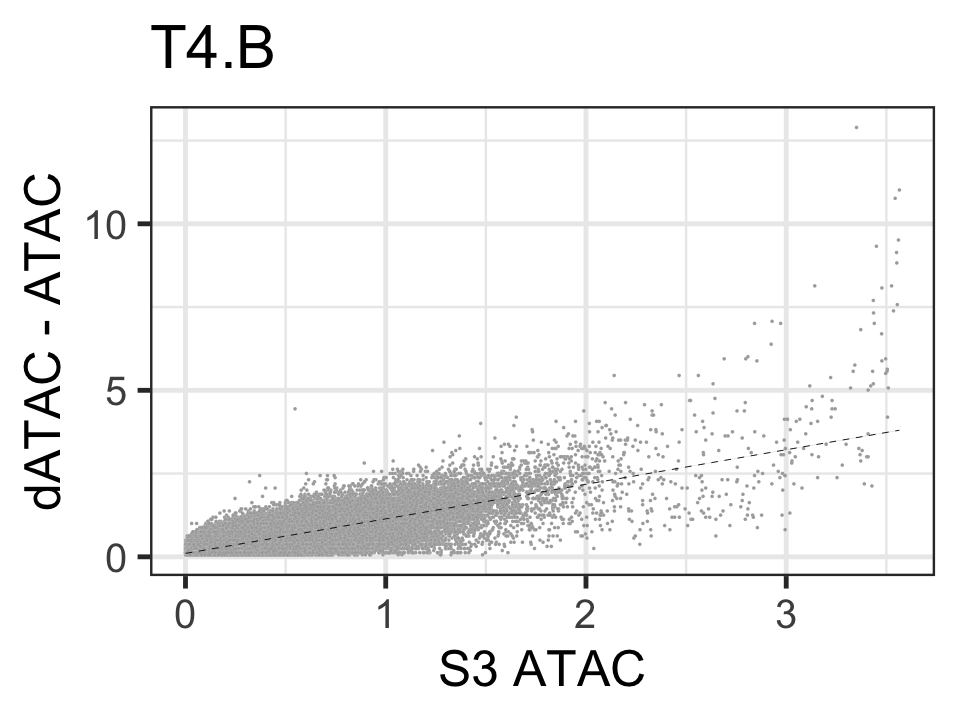

`geom_smooth()` using formula = 'y ~ x'


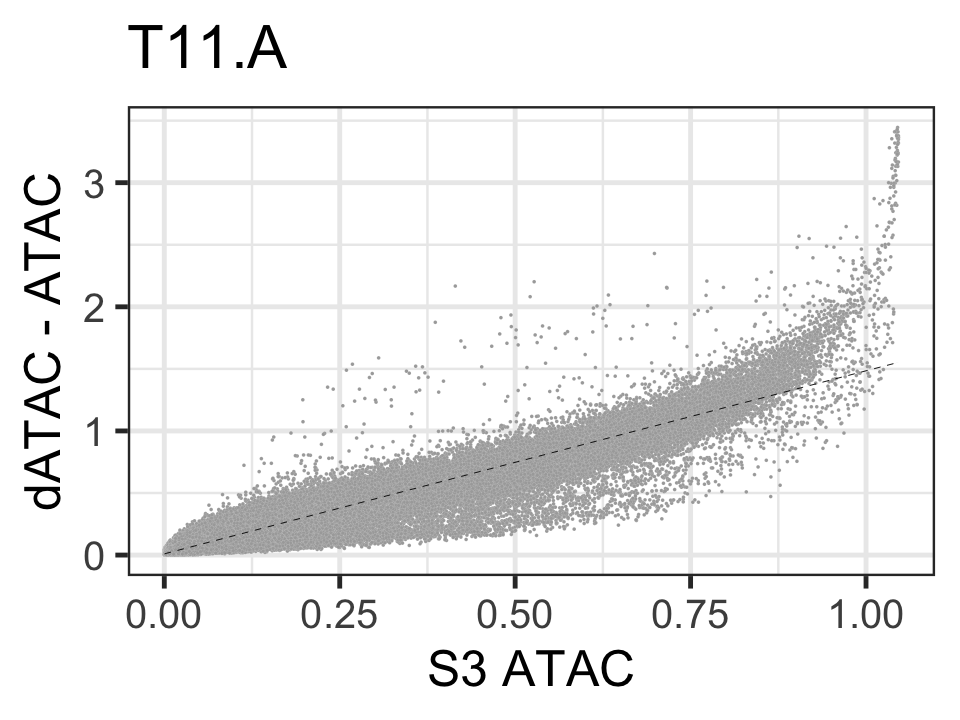

`geom_smooth()` using formula = 'y ~ x'


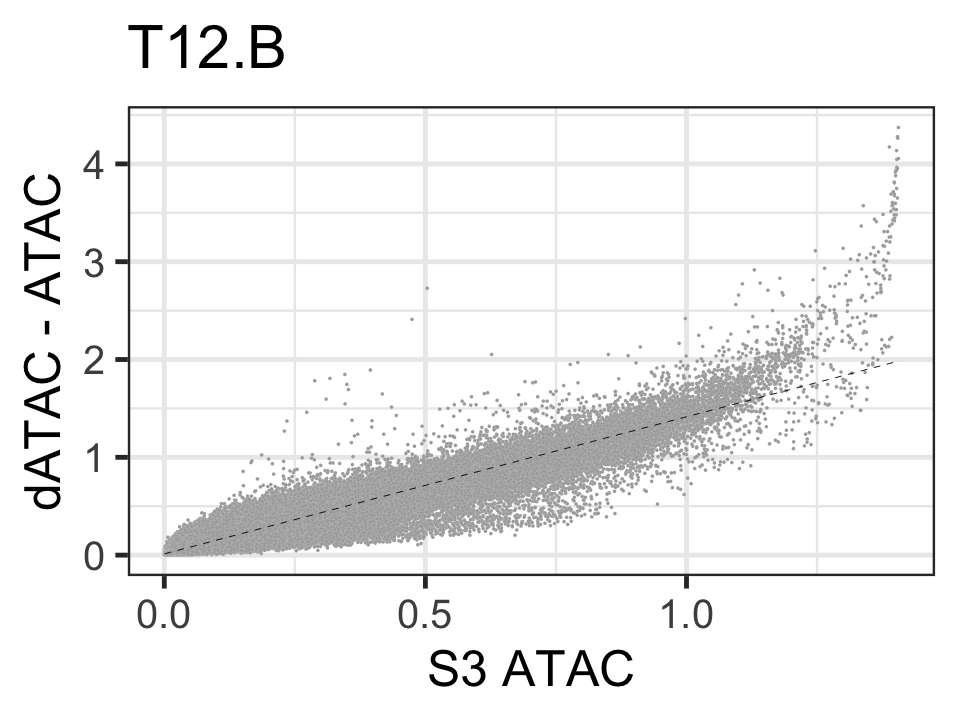

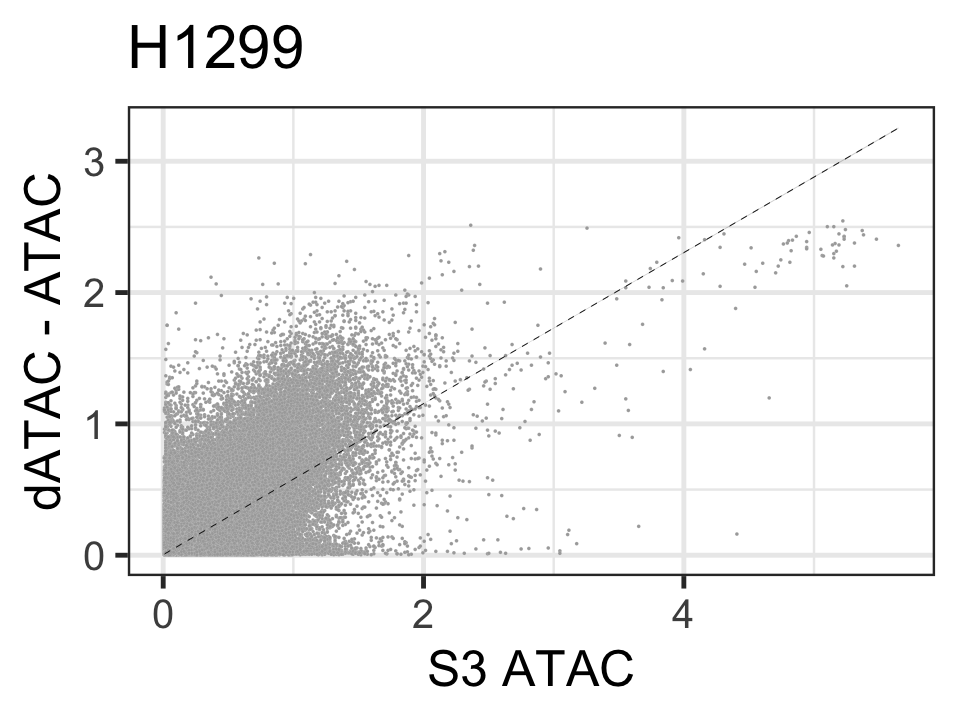

In [13]:
bigwigs <- list.files(path = "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results_New/GroupBigWigs/RepMode",
                      pattern = ".bw", full.names = T)

replicates <- c("T0.A", "T0.B","T1.A", "T1.B","T4.A", "T4.B","T11.A", "T12.B","H1299")

cor_data <- c()
for (r in replicates){
  bw <- bigwigs[grep(r,bigwigs)]
  
  c0_bw <- import.bw(bw[1])
  c1_bw <- import.bw(bw[2])
  
  # 1 Create a common tiling by disjoining both
  common <- disjoin(c(c0_bw, c1_bw))
  
  # 2 Map scores (or other metadata) from each gr back to common bins
  map_scores <- function(from, common) {
    hits <- findOverlaps(common, from)
    mcols(common)$score <- NA  # or whatever metadata columns you want
    mcols(common)$score[queryHits(hits)] <- mcols(from)$score[subjectHits(hits)]
    common
  }
  
  c0_bw_common <- map_scores(c0_bw, common)
  c1_bw_common <- map_scores(c1_bw, common)
  
  mcols(c0_bw_common)[is.na(mcols(c0_bw_common)$score), "score"] <- 0
  mcols(c1_bw_common)[is.na(mcols(c1_bw_common)$score), "score"] <- 0
  
  df <- data.frame("range" = 1:length(c0_bw_common), "SN_0" = c0_bw_common$score, "SN_1" = c1_bw_common$score)
  df <- df %>% filter(SN_0 > 0 & SN_1 > 0)
  
  t <- cor.test(df$SN_0, df$SN_1, method = "pearson")
  cor_data <- rbind(cor_data,cbind("sample" = r, "R" = round(t$estimate,3), "p" = t$p.value))
  
  p <- ggplot(df, aes(x = SN_1, y = SN_0))+
    geom_point(shape = 21, fill = "darkgrey",color = "white", stroke = 0.04, size = 1)+
    geom_smooth(method = "lm",alpha = 0.2, fill = "black", color = "black", linewidth = 0.25, linetype = "dashed")+
    labs(title = sprintf("%s",r))+
    ylab("dATAC - ATAC")+
    xlab("S3 ATAC")+
    guides(color = "none", fill = "none")+
    theme_bw(base_size = 30)
    options(repr.plot.width=8, repr.plot.height=6)
    print(p)
}

#### Correlation scores for each sample

In [14]:
cor_data

,sample,R,p
cor,T0.A,0.931,0
cor,T0.B,0.833,0
cor,T1.A,0.929,0
cor,T1.B,0.94,0
cor,T4.A,0.802,0
cor,T4.B,0.844,0
cor,T11.A,0.967,0
cor,T12.B,0.964,0
cor,H1299,0.74,0


## Compare s3-ATAC and dATAC library complexity

In [15]:
library("readxl")
lib_complexity_1 <- data.frame(read_excel("../../Data/ATAC_Data/QC/SW620_H1299_MCF7_multiqc_picard_dups.xlsx",
                                          sheet = "SW620_BATCH01",
                                          col_types = c(rep("text", 3),rep("numeric", 13),"text"))) 

lib_complexity_1 <- lib_complexity_1[grep("LibraryComplexity",lib_complexity_1$Sample),] %>%
  mutate(new_id = gsub("59|.sort.LibraryComplexity","",Sample))


atac_barcodes <- data.frame(read_excel("../../Data/ATAC_Data/QC/SW620 POT untreated day3 18042024.xlsx",
                                       sheet = "S3_ATAC indexes",
                                       col_types = "text")) 
atac_barcodes <-atac_barcodes %>% 
  select(Sample_Name,Barcode) %>% rename(Sample_Barcode = Barcode) 

atac_barcodes <-atac_barcodes %>% mutate(prefix = sub(".*ATAC#", "", atac_barcodes$Sample_Barcode))

og_names <- proj[proj$Sample %in% c("SW620bc_POTa_ATAC","SW620bc_POTb_ATAC"),]$cellNames

# Extract barcode after `ATAC#`
barcode <- sub(".*ATAC#", "", og_names)

# Define prefix length (adjust if needed)
prefix_len <- 18
suffix_len <- 8

# Identify prefix and suffix
prefix <- substr(barcode, 1, prefix_len)
suffix <- substr(barcode, nchar(barcode)-suffix_len+1, nchar(barcode))

df <- data.frame(
  og_id = og_names,
  barcode = barcode,
  prefix = prefix,
  suffix = suffix,
  stringsAsFactors = FALSE
)

df <- df %>% left_join(atac_barcodes, by = "prefix") 

df <- df %>% mutate(new_id = sprintf("%s_%s",Sample_Name, suffix)) %>% left_join(data.frame("og_id" = proj$cellNames, "sample" = proj@cellColData$Sample), by = "og_id")

#POTa/POTb ATAC
lib_complexity_pot <- lib_complexity_1[lib_complexity_1$new_id %in% df$new_id,] %>% left_join(df[,c("new_id","sample")], by = "new_id")

write_csv(lib_complexity_pot[,c(1:2,4:16,18:19)],"../../Data/ATAC_Data/QC/Processed_ATAC_POT_LibraryComplexities.csv" )

# POTa datac
pota_datac_names <- sub(".*DATAC#", "",rownames(proj@cellColData[proj@cellColData$Sample == "SW620bc_POTa_DATAC",]))
lib_complexity_pota_datac  <- lib_complexity_1[lib_complexity_1$new_id %in% pota_datac_names,] %>% mutate(sample = "SW620bc_POTa_DATAC")

# POTb datac
potb_datac_names <- sub(".*DATAC#", "",rownames(proj@cellColData[proj@cellColData$Sample == "SW620bc_POTb_DATAC",]))
lib_complexity_potb_datac <- data.frame(read_tsv("../../Data/ATAC_Data/QC/LibComplexity_POTb_DATAC.tsv"))
lib_complexity_potb_datac <- lib_complexity_potb_datac[lib_complexity_potb_datac$Sample %in% potb_datac_names,]%>% mutate(sample = "SW620bc_POTb_DATAC")

# Dataframe
data <- data.frame("sample" = c(lib_complexity_pot$sample, lib_complexity_pota_datac$sample, lib_complexity_potb_datac$sample),
                   "mode" = c(rep("s3-ATAC", nrow(lib_complexity_pot)), rep("dATAC - ATAC", nrow(lib_complexity_pota_datac)), rep("DATAC - ATAC", nrow(lib_complexity_potb_datac))),
                   "cell_id" = c(lib_complexity_pot$new_id, lib_complexity_pota_datac$new_id, lib_complexity_potb_datac$Sample),
                   "libSize" = c(lib_complexity_pot$ESTIMATED_LIBRARY_SIZE, lib_complexity_pota_datac$ESTIMATED_LIBRARY_SIZE, lib_complexity_potb_datac$ESTIMATED_LIBRARY_SIZE),
                   "Duplicates" =c(lib_complexity_pot$PERCENT_DUPLICATION, lib_complexity_pota_datac$PERCENT_DUPLICATION, lib_complexity_potb_datac$PERCENT_DUPLICATION),
                   "UniqueFrags" = c(lib_complexity_pot$READ_PAIRS_EXAMINED - lib_complexity_pot$READ_PAIR_DUPLICATES,
                                     lib_complexity_pota_datac$READ_PAIRS_EXAMINED -  lib_complexity_pota_datac$READ_PAIR_DUPLICATES,
                                     lib_complexity_potb_datac$READ_PAIRS_EXAMINED -  lib_complexity_potb_datac$READ_PAIR_DUPLICATES),
                   "MappedReadPairsMillion" =c(lib_complexity_pot$READ_PAIRS_EXAMINED/1000000, lib_complexity_pota_datac$READ_PAIRS_EXAMINED/1000000, lib_complexity_potb_datac$READ_PAIRS_EXAMINED/1000000) )

data <- data %>% mutate(Rep = case_when(sample %in% c("SW620bc_POTa_ATAC","SW620bc_POTa_DATAC") ~ "T0.A",
  sample %in% c("SW620bc_POTb_ATAC","SW620bc_POTb_DATAC") ~ "T0.B"))

New names:
• `included in analysis` -> `included in analysis...3`
• `included in analysis` -> `included in analysis...17`
New names:
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
Rows: 169 Columns: 11
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Sample, LIBRARY
dbl (9): UNPAIRED_READS_EXAMINED, READ_PAIRS_EXAMINED, SECONDARY_OR_SUPPLEME...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


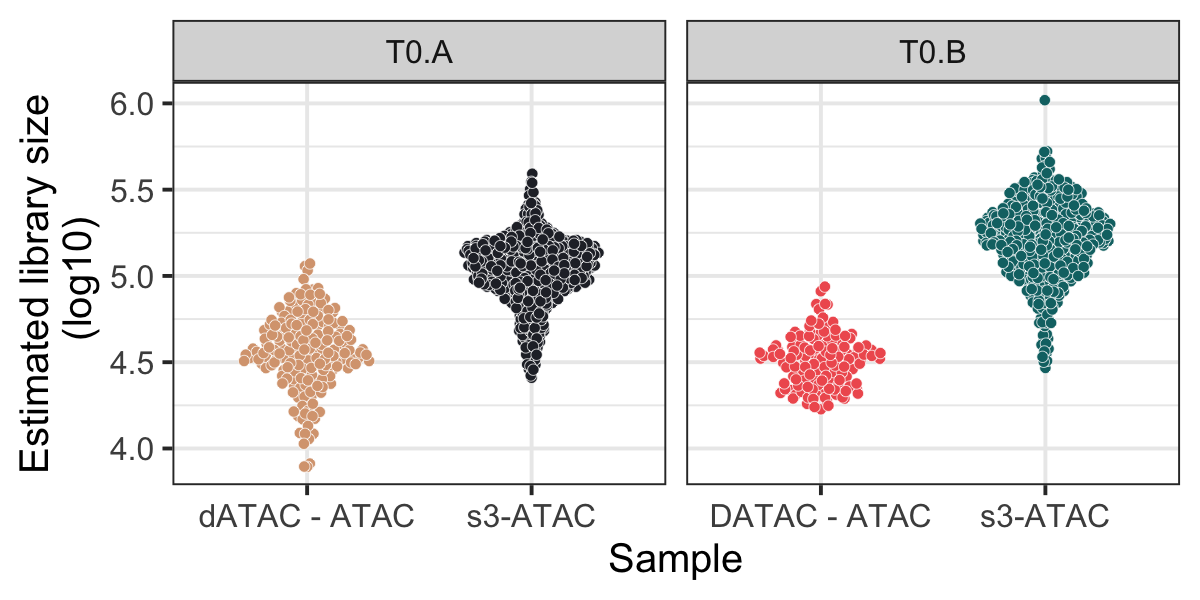

In [16]:
p <- ggplot(data = data, aes(x = mode, y =log10(libSize),  fill = sample))+
  #geom_boxplot(alpha = 0.25, outliers = F) +
  geom_quasirandom(
    dodge.width = 0.8,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3,
    stroke = 0.3,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  scale_color_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                                "SW620bc_POTb_DATAC" ="#f05d5e",
                                "SW620bc_POTb_ATAC" ="#0f7173",
                                "SW620bc_POTa_ATAC" ="#272932"))+
  scale_fill_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                               "SW620bc_POTb_DATAC" ="#f05d5e",
                               "SW620bc_POTb_ATAC" ="#0f7173",
                               "SW620bc_POTa_ATAC" ="#272932"))+
  xlab("Sample")+
  ylab("Estimated library size\n (log10)")+
  facet_wrap(vars(Rep), scales = "free_x", nrow = 1)+
  guides(color = "none", fill = "none")+
  theme_bw(base_size = 24)
options(repr.plot.width=10, repr.plot.height=5)
p

## Browser track at the GAPDH locus

In [19]:
set.seed(1)

my_pal <- c(
  "s3-ATAC: T0.A" = "#730d5d",
  "dATAC - ATAC: T0.A" = "#730d5d",
  "s3-ATAC: T0.B" = "#b81595",
  "dATAC - ATAC: T0.B" = "#b81595",
  "s3-ATAC: T1.A" = "#f077d6",
  "dATAC - ATAC: T1.A" = "#f077d6",
  "s3-ATAC: T1.B" = "#f8bceb",
  "dATAC - ATAC: T1.B" = "#f8bceb",
  "s3-ATAC: T4.A" = "#c9bcf8",
  "dATAC - ATAC: T4.A" = "#c9bcf8",
  "s3-ATAC: T4.B" = "#7e60ef",
  "dATAC - ATAC: T4.B" = "#7e60ef",
  "s3-ATAC: T11.A" = "#a25fef",
  "dATAC - ATAC: T11.A" = "#a25fef",
  "s3-ATAC: T12.B" = "#6113bc",
  "dATAC - ATAC: T12.B" = "#6113bc",
  "s3-ATAC: H1299" = "#ffba49",
  "dATAC - ATAC: H1299" = "#ffba49"
)

track_order <- names(my_pal)

p <- plotBrowserTrack(
  ArchRProj = proj,
  groupBy = "RepMode",
  useGroups = rev(track_order),
  geneSymbol = "GAPDH",
  upstream = 150000,
  downstream = 150000,
  baseSize = 10,
  maxCells = 1000,
  pal = my_pal
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-8bee54bed460-Date-2026-09-11_Time-13-40-00.80707.log
If there is an issue, please report to github with logFile!

2026-09-11 13:40:01.822149 : Validating Region, 0.017 mins elapsed.



GRanges object with 1 range and 2 metadata columns:
      seqnames          ranges strand |     gene_id      symbol
         <Rle>       <IRanges>  <Rle> | <character> <character>
  [1]    chr12 6533927-6538374      + |        2597       GAPDH
  -------
  seqinfo: 24 sequences from hg38 genome


2026-09-11 13:40:01.924336 : Adding Bulk Tracks (1 of 1), 0.019 mins elapsed.

Getting Region From Arrow Files 1 of 18

Getting Region From Arrow Files 2 of 18

Getting Region From Arrow Files 3 of 18

Getting Region From Arrow Files 4 of 18

Getting Region From Arrow Files 5 of 18

Getting Region From Arrow Files 6 of 18

Getting Region From Arrow Files 7 of 18

Getting Region From Arrow Files 8 of 18

Getting Region From Arrow Files 9 of 18

Getting Region From Arrow Files 10 of 18

Getting Region From Arrow Files 11 of 18

Getting Region From Arrow Files 12 of 18

Getting Region From Arrow Files 13 of 18

Getting Region From Arrow Files 14 of 18

Getting Region From Arrow Files 15 of 18

Getting Region From Arrow Files 16 of 18

Getting Region From Arrow Files 17 of 18

Getting Region From Arrow Files 18 of 18

2026-09-11 13:40:10.305395 : Adding Feature Tracks (1 of 1), 0.158 mins elapsed.

2026-09-11 13:40:10.456366 : Adding Gene Tracks (1 of 1), 0.161 mins elapsed.

2026-09-11 13

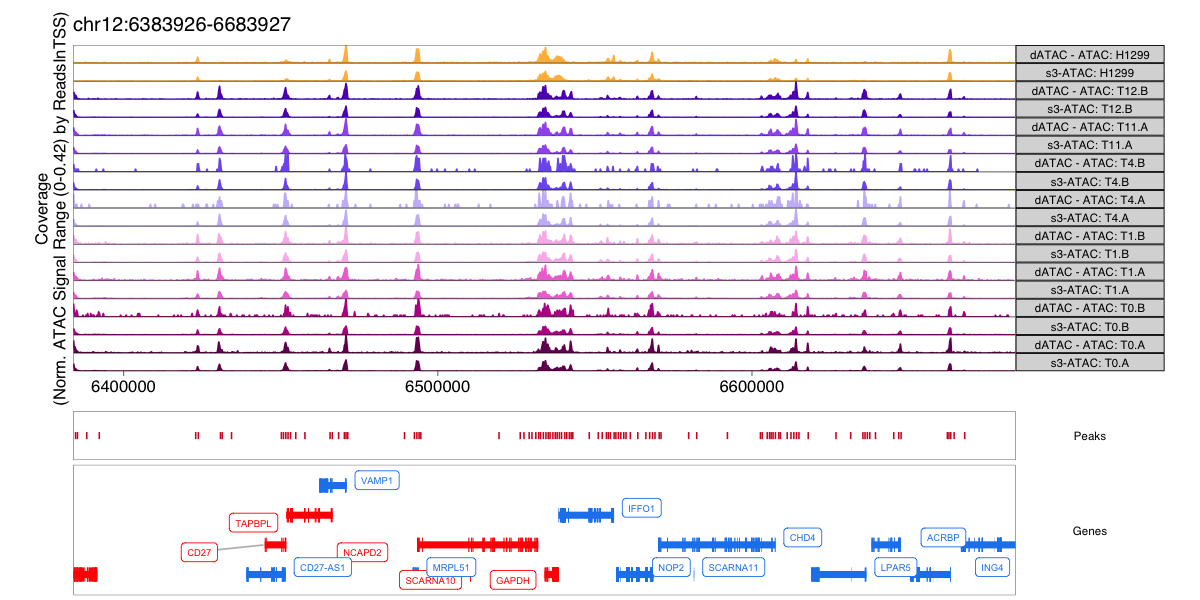

In [20]:
plot(p$GAPDH)

## Proportions of cells that pass each QC step, across timepoint

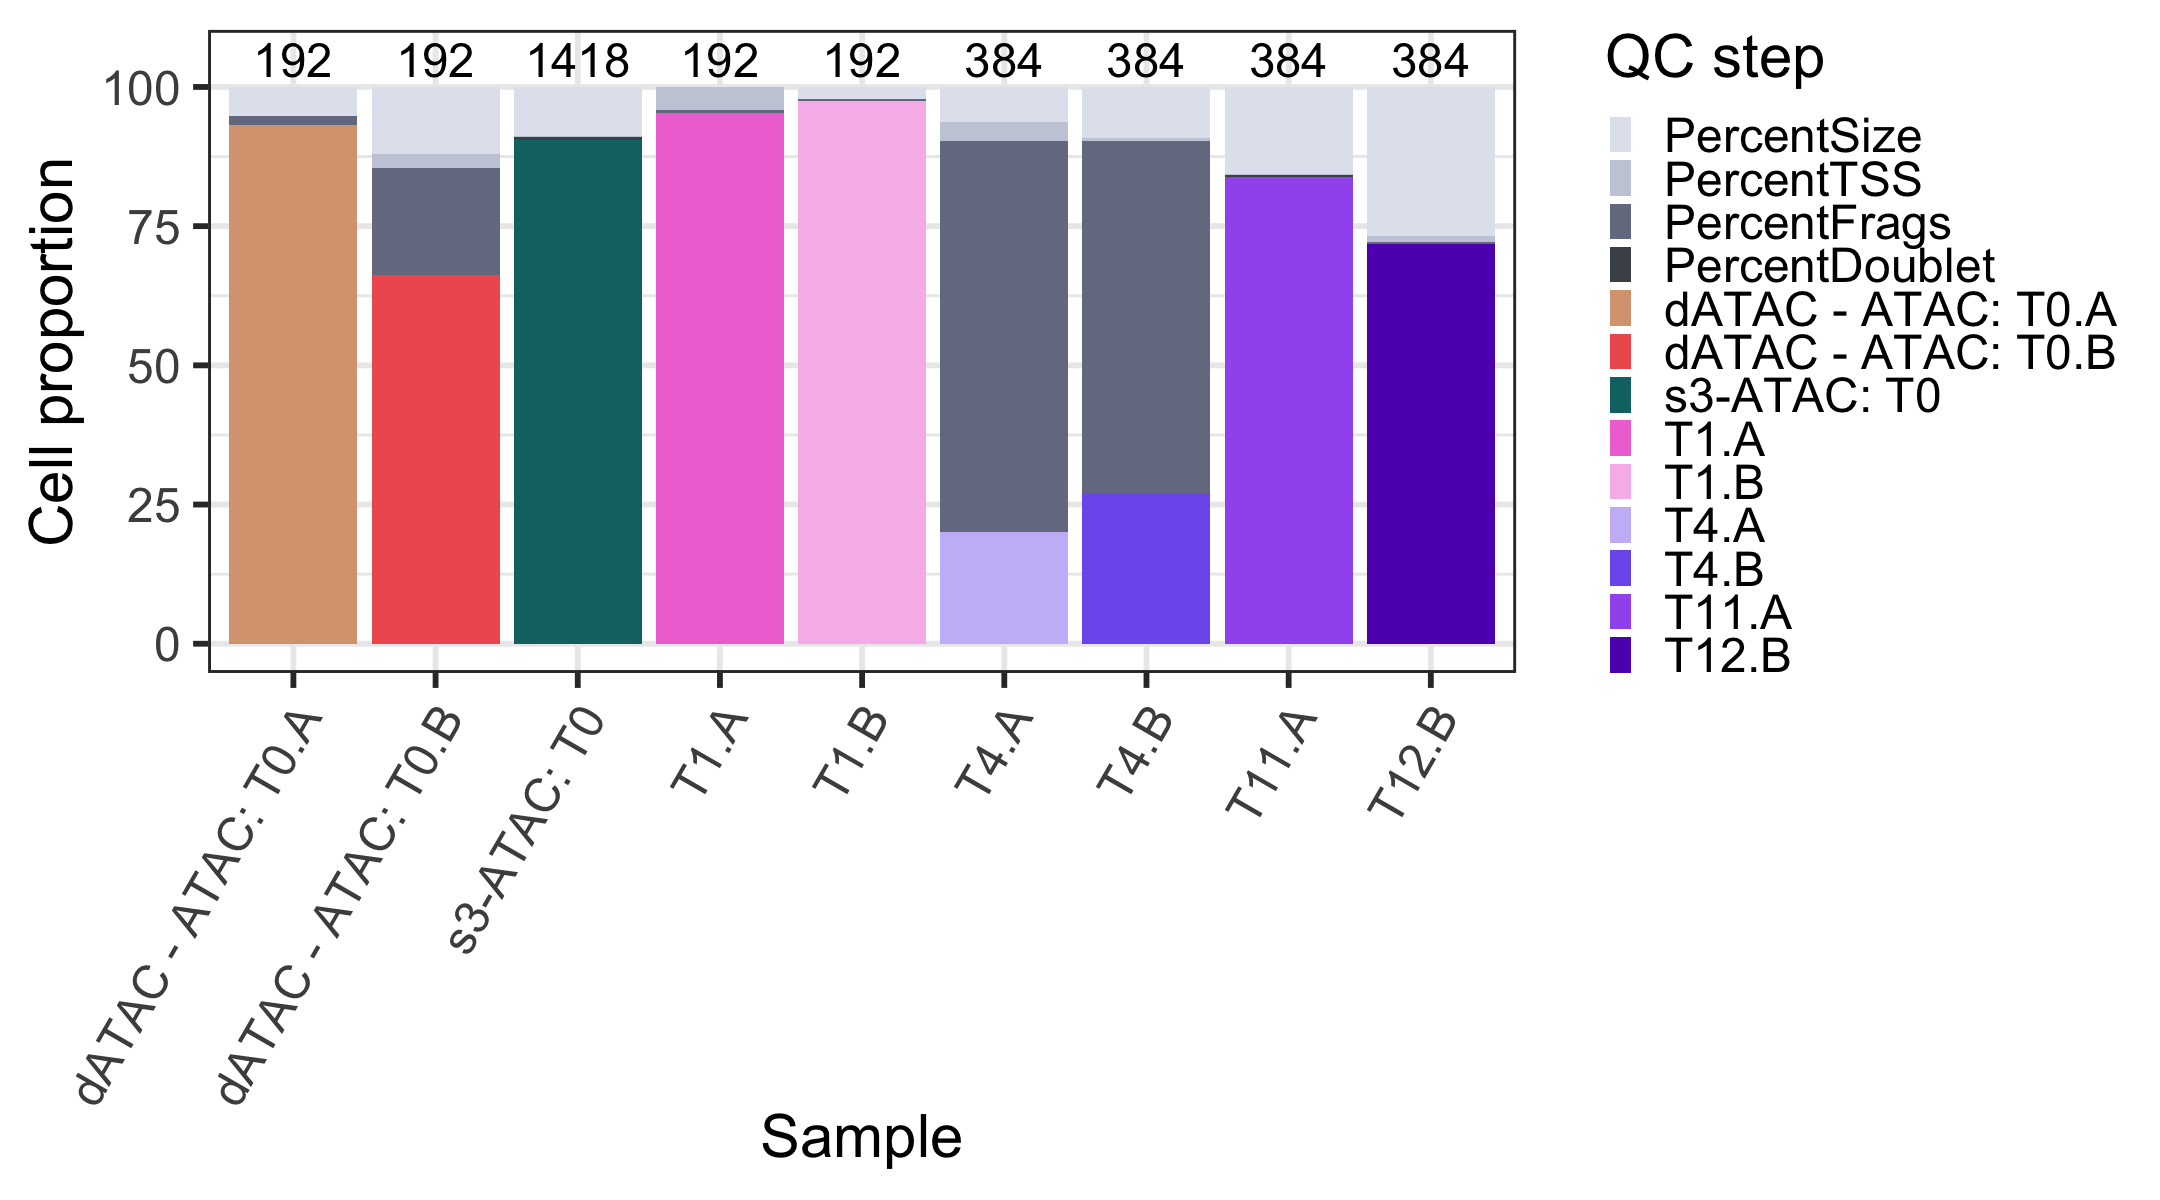

In [123]:
df <- data.frame(read_excel("../../Data/ATAC_Data/QC/ProportionCellsPassQC.xlsx")) 

df_long <- df %>% 
  filter(Sample %in% c("dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                        "T1.A","T1.B", "T4.A","T4.B",
                        "T11.A","T12.B")) %>%
  tidyr::pivot_longer(
    cols = starts_with("Percent"),
    names_to = "QC.metric",
    values_to = "Proportion"
  ) %>% 
 mutate(
    fill_var = if_else(
      QC.metric == "PercentPass",
      Sample,               # colour by sample
      QC.metric             # otherwise use QC.metric
    )
  ) 


df_long$QC.metric <- factor(df_long$QC.metric, levels = c("PercentSize","PercentTSS","PercentFrags","PercentDoublet","PercentPass"))
df_long$Sample <- factor(df_long$Sample, levels = c( "dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                                                        "T1.A","T1.B", "T4.A","T4.B",
                                                        "T11.A","T12.B"))
df_long$fill_var <- factor(df_long$fill_var, levels = c("PercentSize","PercentTSS","PercentFrags","PercentDoublet",
                                                       "dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                                                        "T1.A","T1.B", "T4.A","T4.B",
                                                        "T11.A","T12.B"))

p <- ggplot(data = df_long, aes(x = Sample, y =abs(Proportion),  fill = fill_var))+
  geom_col() +
  scale_fill_manual(name = "QC step",
                    values = c("PercentSize" = "#e1e5ee",
                               "PercentTSS" = "#c7ccdb",
                               "PercentFrags" = "#767b91",
                               "PercentDoublet" = "#495057",
                               "dATAC - ATAC: T0.A" = "#d8a47f",
                               "dATAC - ATAC: T0.B" = "#f05d5e",
                               "s3-ATAC: T0" =  "#0f7173",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc"))+
  geom_text(data = df %>% filter(Sample %in% c("dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                        "T1.A","T1.B", "T4.A","T4.B",
                        "T11.A","T12.B")) %>% select(Sample, Total),
            aes(x =`Sample`, y = 105, label = Total),
            inherit.aes = F,# slightly above the bar
            size = 10
  ) +
  xlab("Sample")+
  ylab("Cell proportion")+
  theme_bw(base_size = 36)+
    theme(
        axis.text.x = element_text(angle = 60, hjust = 1)
    )
options(repr.plot.width=18, repr.plot.height=10)
p


## Venn diagrams of dATAC cells per sample that pass both ATAC and WGS QCs

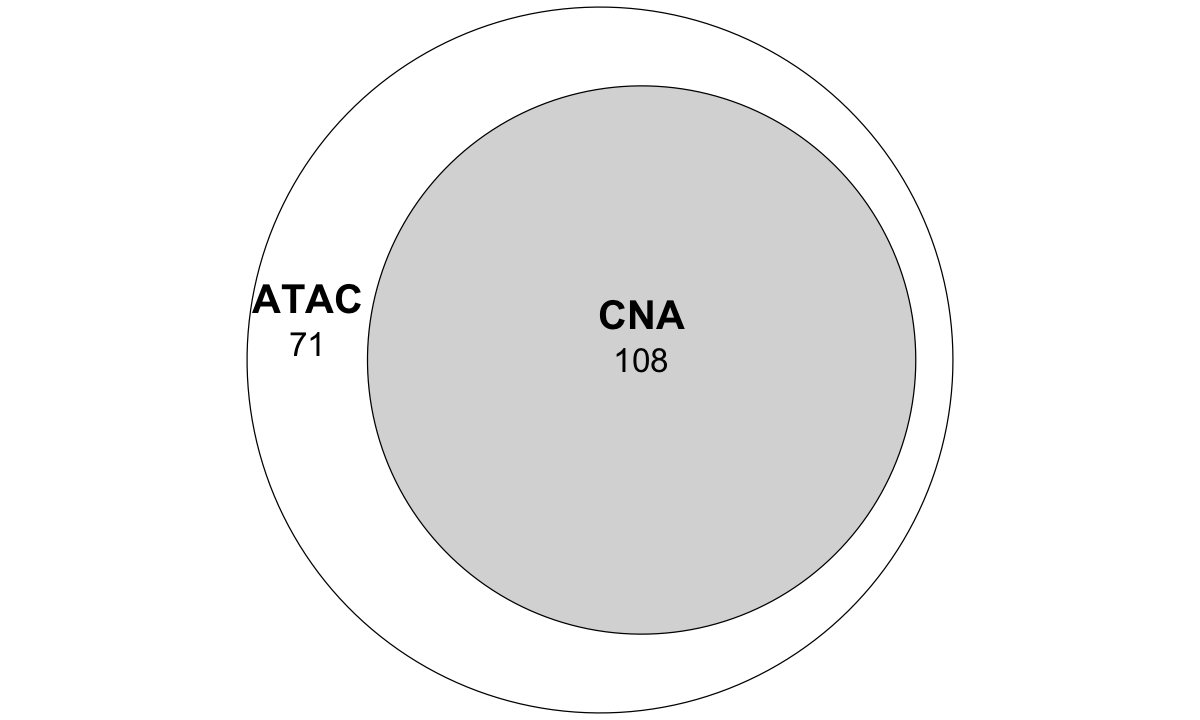

In [98]:
# Venn diagrams for cells passing both CNA and ATAC QC - POTa
options(repr.plot.width=10, repr.plot.height=6)
e <- euler(c("ATAC" = 71,
             "CNA"= 0,
             "ATAC&CNA" = 108))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


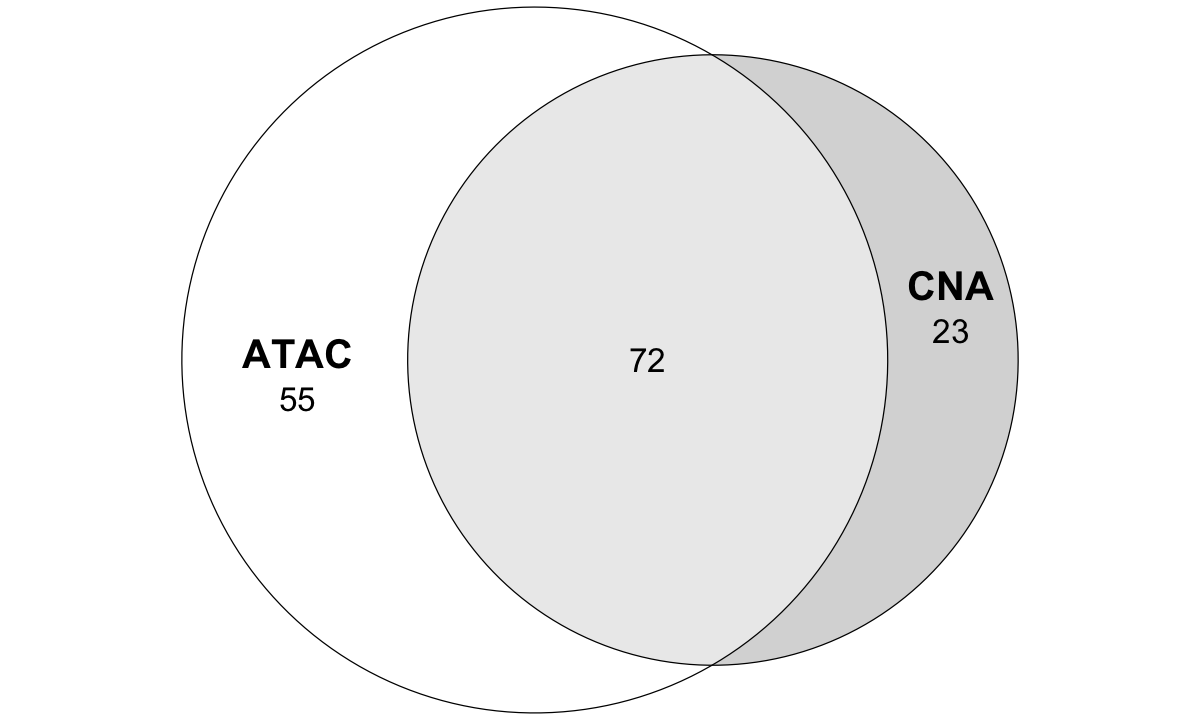

In [99]:
# Venn diagrams for cells passing both CNA and ATAC QC - POTb
options(repr.plot.width=10, repr.plot.height=6)
e <- euler(c("ATAC" = 55,
             "CNA"= 23,
             "ATAC&CNA" = 72))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

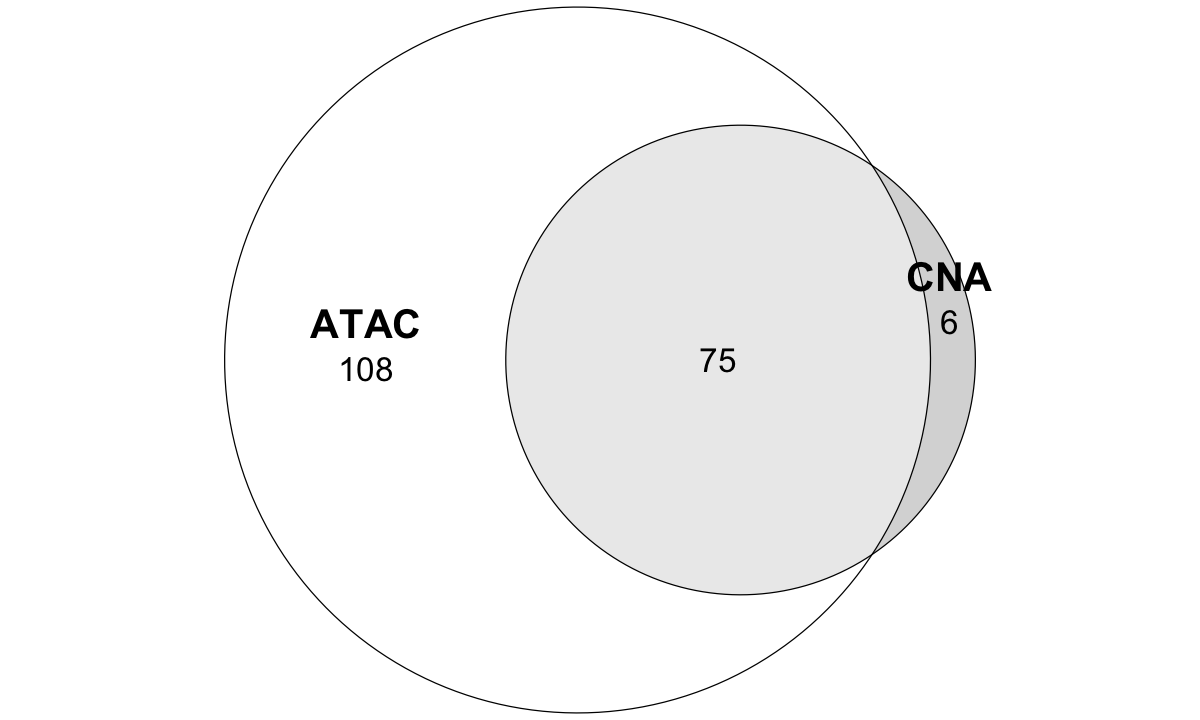

In [100]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIa
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 108,
             "CNA"= 6,
             "ATAC&CNA" = 75))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


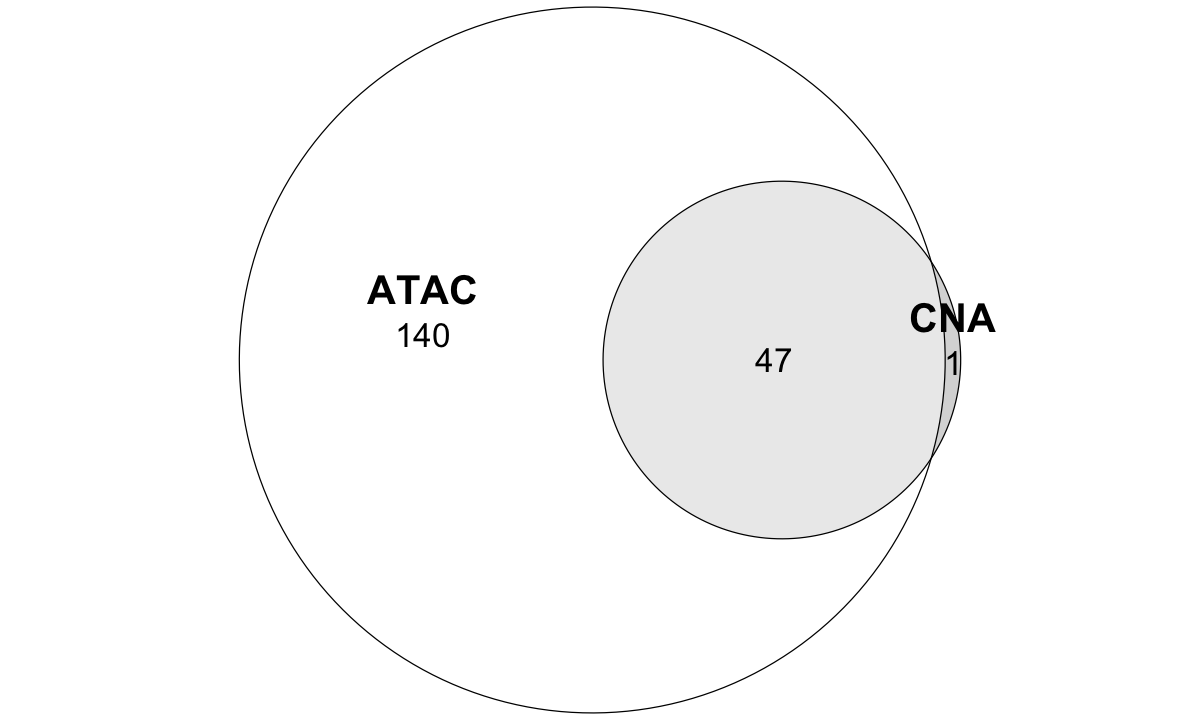

In [101]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIb
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 140,
             "CNA"= 1,
             "ATAC&CNA" = 47))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

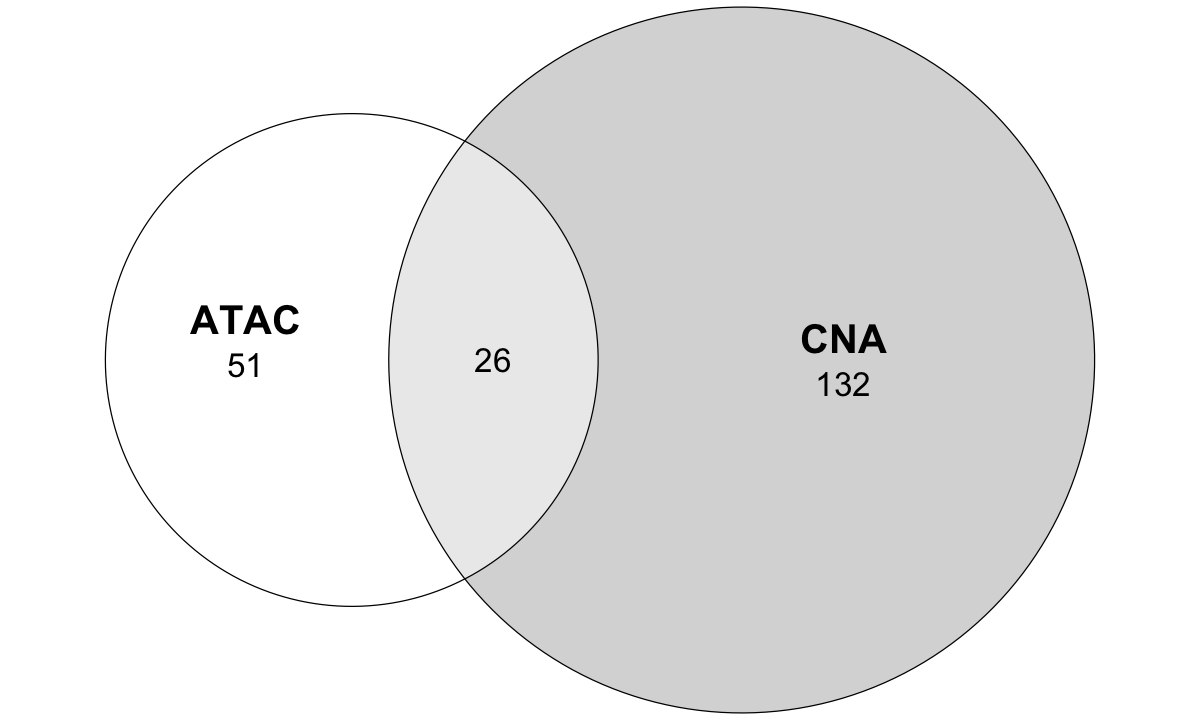

In [105]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIVa
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 51,
             "CNA"= 132,
             "ATAC&CNA" = 26))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


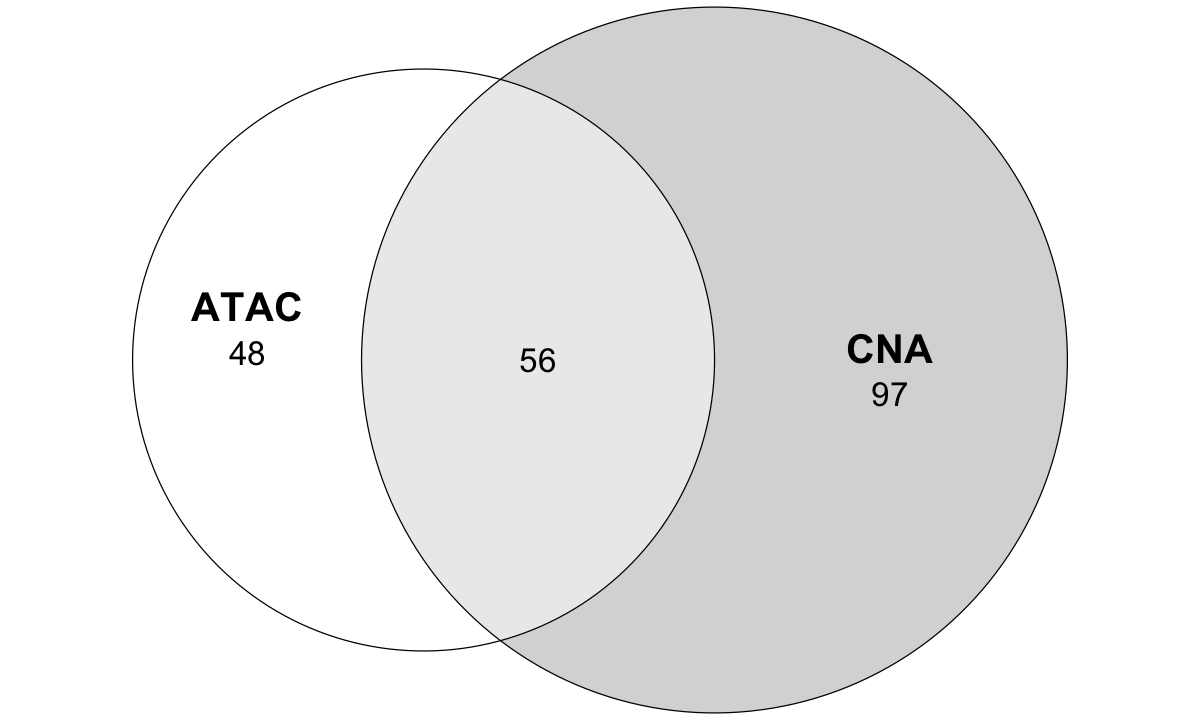

In [106]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIVb
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 48,
             "CNA"= 97,
             "ATAC&CNA" = 56))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

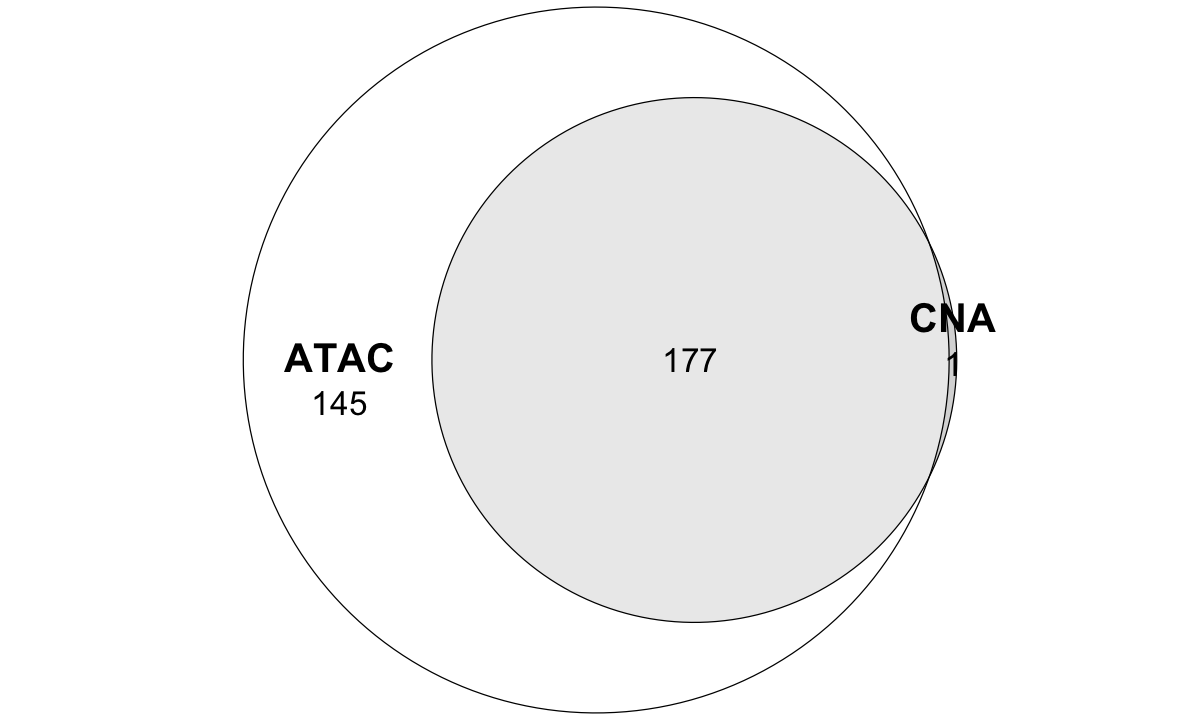

In [107]:
# Venn diagrams for cells passing both CNA and ATAC QC - DT1 P1a
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 145,
             "CNA"= 1,
             "ATAC&CNA" = 177))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


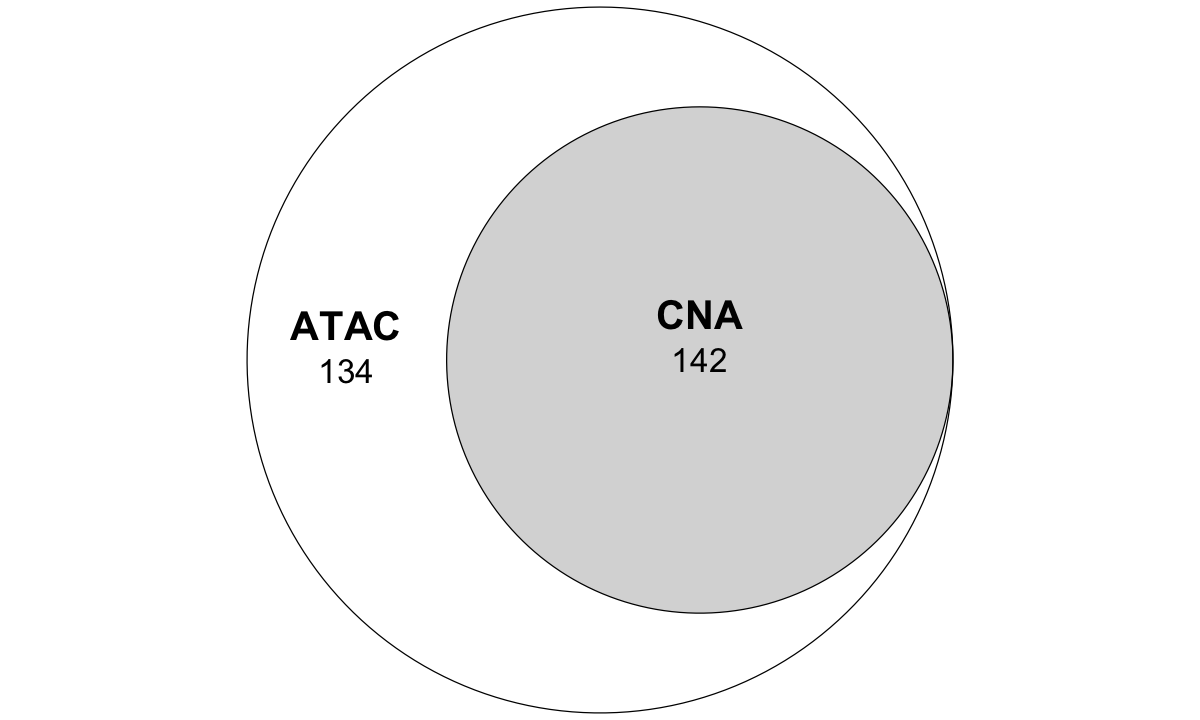

In [104]:
# Venn diagrams for cells passing both CNA and ATAC QC - DT1 P1b
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 134,
             "CNA"= 0,
             "ATAC&CNA" = 142))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))